In [85]:
import numpy as np
import pandas as pd

In [86]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown


In [ ]:
# Final Project: Superstore Business Analysis
# 
# 
# Dataset: Sample Superstore Dataset
# Source: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

print("All libraries imported.")

All libraries imported.


In [88]:
import os
os.getcwd()

'd:\\PYTHON______\\superstore data analysis'

In [89]:
df = pd.read_csv("Data.csv", encoding="latin1")

In [90]:
# SECTION 2: DATA UNDERSTANDING



print("DATASET SHAPE")
print("-" * 30)
print(f"Total Rows and columns   : {df.shape}")


print( "-" * 30)
print("COLUMN NAMES")
print("-" * 30)

for col in df.columns:
    print(col)

DATASET SHAPE
------------------------------
Total Rows and columns   : (9994, 21)
------------------------------
COLUMN NAMES
------------------------------
Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [91]:
print("DATA TYPES OF EACH COLUMN")
print("-" * 30)
print(df.dtypes)

DATA TYPES OF EACH COLUMN
------------------------------
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [92]:
print(f"Shape: {df.shape}")
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [93]:
print("Numerical Columns")
print("-" * 30)
df.describe().round(2)

Numerical Columns
------------------------------


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [94]:
print("MISSING VALUE SUMMARY")
print("-" * 30)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_df)

MISSING VALUE SUMMARY
------------------------------
No missing values found in the dataset.


In [95]:
print("DUPLICATE ROW CHECK")
print("-" * 30)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")

DUPLICATE ROW CHECK
------------------------------
Total duplicate rows found: 0


In [96]:
print("CATEGORICAL COLUMNS - UNIQUE VALUES")
print("" * 30)

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(f"  {df[col].unique()[:6]}")

CATEGORICAL COLUMNS - UNIQUE VALUES


Order ID (5009 unique values):
  <StringArray>
['CA-2016-152156', 'CA-2016-138688', 'US-2015-108966', 'CA-2014-115812',
 'CA-2017-114412', 'CA-2016-161389']
Length: 6, dtype: str

Order Date (1237 unique values):
  <StringArray>
['11/8/2016', '6/12/2016', '10/11/2015', '6/9/2014', '4/15/2017', '12/5/2016']
Length: 6, dtype: str

Ship Date (1334 unique values):
  <StringArray>
['11/11/2016', '6/16/2016', '10/18/2015', '6/14/2014', '4/20/2017',
 '12/10/2016']
Length: 6, dtype: str

Ship Mode (4 unique values):
  <StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

Customer ID (793 unique values):
  <StringArray>
['CG-12520', 'DV-13045', 'SO-20335', 'BH-11710', 'AA-10480', 'IM-15070']
Length: 6, dtype: str

Customer Name (793 unique values):
  <StringArray>
[    'Claire Gute', 'Darrin Van Huff',  'Sean O'Donnell', 'Brosina Hoffman',
    'Andrew Allen',    'Irene Maddox']
Length: 6, dtype: str

Segment (3 u


City (531 unique values):
  <StringArray>
[      'Henderson',     'Los Angeles', 'Fort Lauderdale',         'Concord',
         'Seattle',      'Fort Worth']
Length: 6, dtype: str

State (49 unique values):
  <StringArray>
['Kentucky', 'California', 'Florida', 'North Carolina', 'Washington', 'Texas']
Length: 6, dtype: str

Region (4 unique values):
  <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

Product ID (1862 unique values):
  <StringArray>
['FUR-BO-10001798', 'FUR-CH-10000454', 'OFF-LA-10000240', 'FUR-TA-10000577',
 'OFF-ST-10000760', 'FUR-FU-10001487']
Length: 6, dtype: str

Category (3 unique values):
  <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

Sub-Category (17 unique values):
  <StringArray>
['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', 'Furnishings']
Length: 6, dtype: str

Product Name (1850 unique values):
  <StringArray>
[                               'Bush Somerset Collection Bookcase',
      'H

C:\Users\user\AppData\Local\Temp\ipykernel_5612\335442300.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [97]:
# SECTION 3: DATA CLEANING


# Step 1: Standardize column names
# Problem: Column names have spaces which causes issues in code
# Solution: Replace spaces with underscores, make lowercase
# Reason: Clean column names make the code more readable and error-free

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

print("Cleaned Column Names:")
for col in df.columns:
    print(f"  - {col}")

Cleaned Column Names:
  - row_id
  - order_id
  - order_date
  - ship_date
  - ship_mode
  - customer_id
  - customer_name
  - segment
  - country
  - city
  - state
  - postal_code
  - region
  - product_id
  - category
  - sub_category
  - product_name
  - sales
  - quantity
  - discount
  - profit


In [98]:
# Step 2: Convert date columns to datetime format
# Problem: 'order_date' and 'ship_date' are stored as plain strings
# Solution: Convert them to proper datetime objects
# Reason: Without this, we cannot extract month, year, or calculate
#          shipping duration — which we need for feature engineering

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

print("Date columns converted successfully!")
print(f"\norder_date dtype : {df['order_date'].dtype}")
print(f"ship_date dtype  : {df['ship_date'].dtype}")
print(f"\nSample order dates:\n{df['order_date'].head()}")

Date columns converted successfully!

order_date dtype : datetime64[us]
ship_date dtype  : datetime64[us]

Sample order dates:
0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: order_date, dtype: datetime64[us]


In [99]:
# Step 3: Identify and flag loss-making orders
# Problem: Some orders have negative profit which means the business
#          is losing money on those transactions
# Solution: Create a flag column 'is_loss' to mark these rows
# Reason: Instead of removing them (they are real data), we flag them
#         so we can analyze loss patterns separately later

df['is_loss'] = df['profit'] < 0

total_loss_orders = df['is_loss'].sum()
loss_pct = (total_loss_orders / len(df) * 100).round(2)

print(f"Total loss-making orders : {total_loss_orders}")
print(f"Percentage of all orders : {loss_pct}%")
print(f"\nSample loss-making rows:")
df[df['is_loss'] == True][['order_id', 'category', 'sales', 'profit']].head()

Total loss-making orders : 1871
Percentage of all orders : 18.72%

Sample loss-making rows:


,order_id,category,sales,profit
3,US-2015-108966,Furniture,957.5775,-383.0310
14,US-2015-118983,Office Supplies,68.8100,-123.8580
15,US-2015-118983,Office Supplies,2.5440,-3.8160
23,US-2017-156909,Furniture,71.3720,-1.0196
27,US-2015-150630,Furniture,3083.4300,-1665.0522


In [100]:
# Step 4: Standardize text case in categorical columns
# Problem: Text inconsistencies like 'WEST', 'West', 'west' can cause
#          incorrect grouping results
# Solution: Apply title case to all object type columns
# Reason: Ensures groupby and comparison operations work correctly

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

print("Text case standardized for columns:")
for col in cat_cols:
    print(f"  - {col}")

print(f"\nSample Region values after fix: {df['region'].unique()}")
print(f"Sample Category values after fix: {df['category'].unique()}")

Text case standardized for columns:
  - order_id
  - ship_mode
  - customer_id
  - customer_name
  - segment
  - country
  - city
  - state
  - region
  - product_id
  - category
  - sub_category
  - product_name

Sample Region values after fix: <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
Sample Category values after fix: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str


C:\Users\user\AppData\Local\Temp\ipykernel_5612\135770022.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [101]:
# Step 5: Drop columns irrelevant to our analysis
# Problem: Columns like 'row_id', 'customer_name', 'postal_code'
#          are identifiers that add no analytical value
# Solution: Drop them from the working dataframe
# Reason: Reduces noise, keeps the dataset focused on what matters

cols_to_drop = ['row_id', 'customer_name', 'postal_code', 'country']

# Only drop if they exist
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"\nRemaining columns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}")

Dropped columns: ['row_id', 'customer_name', 'postal_code', 'country']

Remaining columns (18):
  - order_id
  - order_date
  - ship_date
  - ship_mode
  - customer_id
  - segment
  - city
  - state
  - region
  - product_id
  - category
  - sub_category
  - product_name
  - sales
  - quantity
  - discount
  - profit
  - is_loss


In [102]:


# SECTION 4: FEATURE ENGINEERING


# Feature 1: Extract time-based columns from order_date
# Reason: Raw date alone cannot tell us seasonal trends or yearly
#         growth. Extracting month, year, quarter allows us to
#         analyze sales patterns over time.

df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter

# Month name for better readability in charts
df['month_name'] = df['order_date'].dt.strftime('%b')

print("Time-based features created successfully!")
print(f"\nUnique Years    : {sorted(df['order_year'].unique())}")
print(f"Unique Quarters : {sorted(df['order_quarter'].unique())}")
print(f"\nSample:")
df[['order_date', 'order_year', 'order_month', 'order_quarter', 'month_name']].head()



Time-based features created successfully!

Unique Years    : [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Unique Quarters : [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]

Sample:


,order_date,order_year,order_month,order_quarter,month_name
0,2016-11-08,2016,11,4,Nov
1,2016-11-08,2016,11,4,Nov
2,2016-06-12,2016,6,2,Jun
3,2015-10-11,2015,10,4,Oct
4,2015-10-11,2015,10,4,Oct


In [103]:
# Feature 2: Shipping duration (days between order and ship date)
# Reason: Faster shipping may relate to higher customer satisfaction
#         and repeat purchases. This lets us analyze shipping
#         efficiency across regions and segments.

df['shipping_duration'] = (df['ship_date'] - df['order_date']).dt.days

print("Shipping duration feature created!")
print(f"\nAverage shipping duration : {df['shipping_duration'].mean():.2f} days")
print(f"Max shipping duration     : {df['shipping_duration'].max()} days")
print(f"Min shipping duration     : {df['shipping_duration'].min()} days")
print(f"\nSample:")
df[['order_date', 'ship_date', 'shipping_duration']].head()

Shipping duration feature created!

Average shipping duration : 3.96 days
Max shipping duration     : 7 days
Min shipping duration     : 0 days

Sample:


,order_date,ship_date,shipping_duration
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [104]:
# Feature 3: Profit margin percentage
# Reason: Raw profit numbers are misleading. A $100 profit on $200
#         sales (50%) is far better than $100 profit on $2000 sales
#         (5%). Profit margin reveals true business efficiency.

df['profit_margin'] = ((df['profit'] / df['sales']) * 100).round(2)

print("Profit margin feature created!")
print(f"\nAverage profit margin : {df['profit_margin'].mean():.2f}%")
print(f"Highest margin        : {df['profit_margin'].max():.2f}%")
print(f"Lowest margin         : {df['profit_margin'].min():.2f}%")
print(f"\nSample:")
df[['sales', 'profit', 'profit_margin']].head()

Profit margin feature created!

Average profit margin : 12.03%
Highest margin        : 50.00%
Lowest margin         : -275.00%

Sample:


,sales,profit,profit_margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [105]:
# Feature 4: Discount category (None / Low / Medium / High)
# Reason: Raw discount values (0.1, 0.2 etc.) are hard to compare.
#         Grouping them into categories lets us analyze whether
#         heavy discounts are actually hurting profit.

def categorize_discount(d):
    if d == 0:
        return 'No Discount'
    elif d <= 0.2:
        return 'Low'
    elif d <= 0.4:
        return 'Medium'
    else:
        return 'High'

df['discount_category'] = df['discount'].apply(categorize_discount)

print("Discount category feature created!")
print(f"\nDiscount category distribution:")
print(df['discount_category'].value_counts())

Discount category feature created!

Discount category distribution:
discount_category
No Discount    4798
Low            3803
High            933
Medium          460
Name: count, dtype: int64


In [106]:
# Feature 5: Sales performance category per order
# Reason: Labeling each order as Low / Medium / High / Premium
#         based on sales amount allows quick segmentation and
#         helps identify which tier drives the most revenue.

sales_33 = df['sales'].quantile(0.33)
sales_66 = df['sales'].quantile(0.66)
sales_90 = df['sales'].quantile(0.90)

def sales_category(s):
    if s <= sales_33:
        return 'Low'
    elif s <= sales_66:
        return 'Medium'
    elif s <= sales_90:
        return 'High'
    else:
        return 'Premium'

df['sales_category'] = df['sales'].apply(sales_category)

print("Sales category feature created!")
print(f"\nSales category distribution:")
print(df['sales_category'].value_counts())

Sales category feature created!

Sales category distribution:
sales_category
Low        3298
Medium     3298
High       2398
Premium    1000
Name: count, dtype: int64


In [107]:

print("FEATURE ENGINEERING SUMMARY")
print("-" * 30)

new_features = [
    'order_year', 'order_month', 'order_quarter',
    'month_name', 'shipping_duration',
    'profit_margin', 'discount_category', 'sales_category'
]

print(f"Total features : {len(new_features)}")
print(f"\nNew feature columns:")
for f in new_features:
    print(f"  - {f}")

print(f"\nDataset shape now : {df.shape}")
print(f"\nSample of engineered features:")
df[['sales', 'profit', 'profit_margin',
    'discount_category', 'sales_category',
    'shipping_duration', 'order_year',
    'order_quarter']].head()

FEATURE ENGINEERING SUMMARY
------------------------------
Total features : 8

New feature columns:
  - order_year
  - order_month
  - order_quarter
  - month_name
  - shipping_duration
  - profit_margin
  - discount_category
  - sales_category

Dataset shape now : (9994, 26)

Sample of engineered features:


,sales,profit,profit_margin,discount_category,sales_category,shipping_duration,order_year,order_quarter
0,261.9600,41.9136,16.00,No Discount,High,3,2016,4
1,731.9400,219.5820,30.00,No Discount,Premium,3,2016,4
2,14.6200,6.8714,47.00,No Discount,Low,4,2016,2
3,957.5775,-383.0310,-40.00,High,Premium,7,2015,4
4,22.3680,2.5164,11.25,Low,Low,7,2015,4


In [108]:
# SECTION 5: DATA ANALYSIS


# Analysis 1: Region-wise profit and sales comparison
# Type: Subgroup Comparison
# Question: Which regions are most and least profitable?

region_analysis = df.groupby('region').agg(
    Total_Sales   = ('sales', 'sum'),
    Total_Profit  = ('profit', 'sum'),
    Total_Orders  = ('order_id', 'count'),
    Avg_Margin    = ('profit_margin', 'mean')
).round(2).sort_values('Total_Profit', ascending=False)


print("ANALYSIS 1: REGION-WISE PERFORMANCE")
print("-" * 30)
print(region_analysis)
print(f"\nMost profitable region  : {region_analysis['Total_Profit'].idxmax()}")
print(f"Least profitable region : {region_analysis['Total_Profit'].idxmin()}")

ANALYSIS 1: REGION-WISE PERFORMANCE
------------------------------
         Total_Sales  Total_Profit  Total_Orders  Avg_Margin
region                                                      
West       725457.82     108418.45          3203       21.95
East       678781.24      91522.78          2848       16.72
South      391721.90      46749.43          1620       16.35
Central    501239.89      39706.36          2323      -10.41

Most profitable region  : West
Least profitable region : Central


In [109]:
# Analysis 2: Category and Sub-category wise comparison
# Type: Subgroup Comparison
# Question: Which product categories generate profit vs loss?

category_analysis = df.groupby('category').agg(
    Total_Sales   = ('sales', 'sum'),
    Total_Profit  = ('profit', 'sum'),
    Total_Orders  = ('order_id', 'count'),
    Avg_Margin    = ('profit_margin', 'mean')
).round(2).sort_values('Total_Profit', ascending=False)


print("ANALYSIS 2: CATEGORY-WISE PERFORMANCE")
print("-" * 55)
print(category_analysis)

# Sub-category breakdown
print("\nTop 5 Most Profitable Sub-Categories:")
sub_profit = df.groupby('sub_category')['profit'].sum().sort_values(ascending=False)
print(sub_profit.head())

print("\nTop 5 Loss-Making Sub-Categories:")
print(sub_profit.tail())

ANALYSIS 2: CATEGORY-WISE PERFORMANCE
-------------------------------------------------------
                 Total_Sales  Total_Profit  Total_Orders  Avg_Margin
category                                                            
Technology         836154.03     145454.95          1847       15.61
Office Supplies    719047.03     122490.80          6026       13.80
Furniture          741999.80      18451.27          2121        3.88

Top 5 Most Profitable Sub-Categories:
sub_category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: profit, dtype: float64

Top 5 Loss-Making Sub-Categories:
sub_category
Machines      3384.7569
Fasteners      949.5182
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: profit, dtype: float64


In [110]:
# Analysis 3: Relationship between discount and profit
# Type: Relationship Analysis
# Question: Does giving higher discounts reduce profit?

discount_profit = df.groupby('discount_category').agg(
    Avg_Profit      = ('profit', 'mean'),
    Avg_Sales       = ('sales', 'mean'),
    Avg_Margin      = ('profit_margin', 'mean'),
    Total_Orders    = ('order_id', 'count')
).round(2)


order = ['No Discount', 'Low', 'Medium', 'High']
discount_profit = discount_profit.reindex(order)


print("ANALYSIS 3: DISCOUNT vs PROFIT RELATIONSHIP")
print("-" * 45)
print(discount_profit)

# Correlation between discount and profit
correlation = df['discount'].corr(df['profit'])
print(f"\nCorrelation (Discount vs Profit) : {correlation:.4f}")
print("Interpretation: Negative value means higher discount = lower profit")

ANALYSIS 3: DISCOUNT vs PROFIT RELATIONSHIP
---------------------------------------------
                   Avg_Profit  Avg_Sales  Avg_Margin  Total_Orders
discount_category                                                 
No Discount             66.90     226.74       34.02          4798
Low                     26.50     222.59       17.44          3803
Medium                 -77.86     509.00      -16.69           460
High                  -106.71     137.87     -108.90           933

Correlation (Discount vs Profit) : -0.2195
Interpretation: Negative value means higher discount = lower profit


In [111]:
# Analysis 4: Monthly and quarterly sales trend
# Type: Trend Analysis
# Question: Which months and quarters perform best?

monthly_sales = df.groupby(['order_year', 'order_month']).agg(
    Total_Sales  = ('sales', 'sum'),
    Total_Profit = ('profit', 'sum')
).round(2).reset_index()

quarterly_sales = df.groupby(['order_year', 'order_quarter']).agg(
    Total_Sales  = ('sales', 'sum'),
    Total_Profit = ('profit', 'sum')
).round(2).reset_index()


print("ANALYSIS 4: QUARTERLY SALES TREND")
print("-" * 40)
print(quarterly_sales)

best_quarter = df.groupby('order_quarter')['sales'].sum().idxmax()
print(f"\nBest performing quarter overall : Q{best_quarter}")

ANALYSIS 4: QUARTERLY SALES TREND
----------------------------------------
    order_year  order_quarter  Total_Sales  Total_Profit
0         2014              1     74447.80       3811.23
1         2014              2     86538.76      11204.07
2         2014              3    143633.21      12804.72
3         2014              4    179627.73      21723.95
4         2015              1     68851.74       9264.94
5         2015              2     89124.19      12190.92
6         2015              3    130259.58      16853.62
7         2015              4    182297.01      23309.12
8         2016              1     93237.18      11441.37
9         2016              2    136082.30      16390.34
10        2016              3    143787.36      15823.60
11        2016              4    236098.75      38139.86
12        2017              1    123144.86      23506.20
13        2017              2    133764.37      15499.21
14        2017              3    196251.96      26985.13
15        201

In [112]:
# Analysis 5: Outlier detection in profit using IQR method
# Type: Outlier / Anomaly Analysis
# Question: Are there unusually high or low profit orders?

Q1 = df['profit'].quantile(0.25)
Q3 = df['profit'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['profit'] < lower_bound) | (df['profit'] > upper_bound)]


print("ANALYSIS 5: PROFIT OUTLIER DETECTION (IQR Method)")
print("-" * 40)
print(f"Q1 (25th percentile)  : {Q1:.2f}")
print(f"Q3 (75th percentile)  : {Q3:.2f}")
print(f"IQR                   : {IQR:.2f}")
print(f"Lower bound           : {lower_bound:.2f}")
print(f"Upper bound           : {upper_bound:.2f}")
print(f"\nTotal outlier orders  : {len(outliers)}")
print(f"% of dataset          : {(len(outliers)/len(df)*100):.2f}%")
print(f"\nTop 5 highest profit outliers:")
print(outliers.nlargest(5, 'profit')[['category', 'sub_category', 'sales', 'profit']])
print(f"\nTop 5 biggest loss outliers:")
print(outliers.nsmallest(5, 'profit')[['category', 'sub_category', 'sales', 'profit']])

ANALYSIS 5: PROFIT OUTLIER DETECTION (IQR Method)
----------------------------------------
Q1 (25th percentile)  : 1.73
Q3 (75th percentile)  : 29.36
IQR                   : 27.64
Lower bound           : -39.72
Upper bound           : 70.82

Total outlier orders  : 1881
% of dataset          : 18.82%

Top 5 highest profit outliers:
             category sub_category     sales     profit
6826       Technology      Copiers  17499.95  8399.9760
8153       Technology      Copiers  13999.96  6719.9808
4190       Technology      Copiers  10499.97  5039.9856
9039  Office Supplies      Binders   9892.74  4946.3700
4098  Office Supplies      Binders   9449.95  4630.4755

Top 5 biggest loss outliers:
             category sub_category     sales     profit
7772       Technology     Machines  4499.985 -6599.9780
683        Technology     Machines  7999.980 -3839.9904
9774  Office Supplies      Binders  2177.584 -3701.8928
3011       Technology     Machines  2549.985 -3399.9800
4991  Office Supplie

In [113]:
# Analysis 6: NumPy-based statistical computation
# Type: Custom NumPy Analysis
# Question: How are profits distributed statistically?

profit_array = df['profit'].to_numpy()
sales_array  = df['sales'].to_numpy()


profit_mean = np.mean(profit_array)
profit_std  = np.std(profit_array)
profit_zscore = (profit_array - profit_mean) / profit_std
df['profit_zscore'] = profit_zscore

# Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
profit_percentiles = np.percentile(profit_array, percentiles)


print("ANALYSIS 6: NUMPY STATISTICAL COMPUTATION")
print("-" * 40)
print(f"Mean      : {np.mean(profit_array):.2f}")
print(f"Median   : {np.median(profit_array):.2f}")
print(f"Std Deviation    : {np.std(profit_array):.2f}")
print(f"Total Revenue    : {np.sum(sales_array):.2f}")

print(f"\nProfit Percentile Breakdown:")
for p, v in zip(percentiles, profit_percentiles):
    print(f"  {p}th percentile : {v:.2f}")


sales_normalized = (sales_array - np.min(sales_array)) / \
                   (np.max(sales_array) - np.min(sales_array))
df['sales_normalized'] = sales_normalized.round(4)

print(f"\nSales normalization range : {df['sales_normalized'].min()} to {df['sales_normalized'].max()}")

ANALYSIS 6: NUMPY STATISTICAL COMPUTATION
----------------------------------------
Mean      : 28.66
Median   : 8.67
Std Deviation    : 234.25
Total Revenue    : 2297200.86

Profit Percentile Breakdown:
  10th percentile : -15.47
  25th percentile : 1.73
  50th percentile : 8.67
  75th percentile : 29.36
  90th percentile : 89.28
  95th percentile : 168.47
  99th percentile : 580.66

Sales normalization range : 0.0 to 1.0


In [114]:
# Analysis 7: Customer segment performance
# Type: Grouping and Aggregation
# Question: Which customer segment is most valuable?

segment_analysis = df.groupby('segment').agg(
    Total_Sales    = ('sales', 'sum'),
    Total_Profit   = ('profit', 'sum'),
    Total_Orders   = ('order_id', 'count'),
    Avg_Order_Value= ('sales', 'mean'),
    Avg_Margin     = ('profit_margin', 'mean')
).round(2).sort_values('Total_Profit', ascending=False)


print("ANALYSIS 7: CUSTOMER SEGMENT PERFORMANCE")
print("-" * 40)
print(segment_analysis)

print(f"\nMost valuable segment : {segment_analysis['Total_Profit'].idxmax()}")
print(f"Highest avg order value : {segment_analysis['Avg_Order_Value'].idxmax()}")

ANALYSIS 7: CUSTOMER SEGMENT PERFORMANCE
----------------------------------------
             Total_Sales  Total_Profit  Total_Orders  Avg_Order_Value  \
segment                                                                 
Consumer      1161401.34     134119.21          5191           223.73   
Corporate      706146.37      91979.13          3020           233.82   
Home Office    429653.15      60298.68          1783           240.97   

             Avg_Margin  
segment                  
Consumer          11.20  
Corporate         12.12  
Home Office       14.29  

Most valuable segment : Consumer
Highest avg order value : Home Office


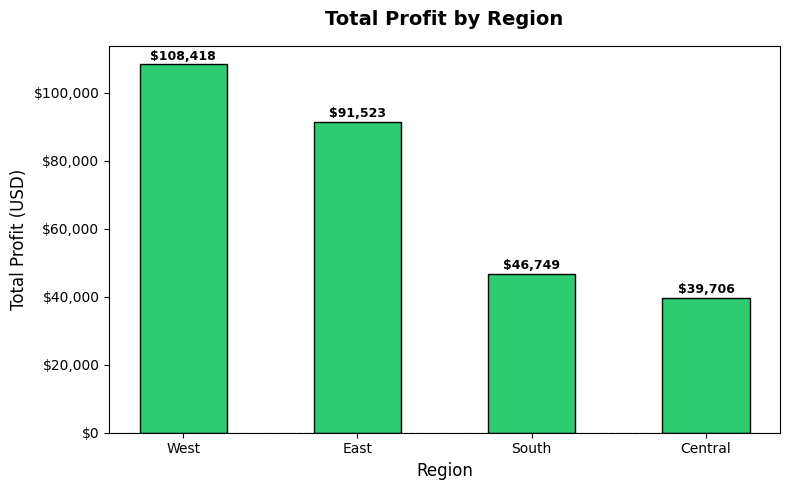

In [115]:

# SECTION 6: VISUALIZATION


# Chart 1: Region wise Total Profit
region_profit = df.groupby('region')['profit'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in region_profit.values]
bars = ax.bar(region_profit.index, region_profit.values, color=colors, edgecolor='black', width=0.5)

ax.set_title('Total Profit by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Total Profit (USD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

for bar, val in zip(bars, region_profit.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'${val:,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_region_profit.png', dpi=150)
plt.show()


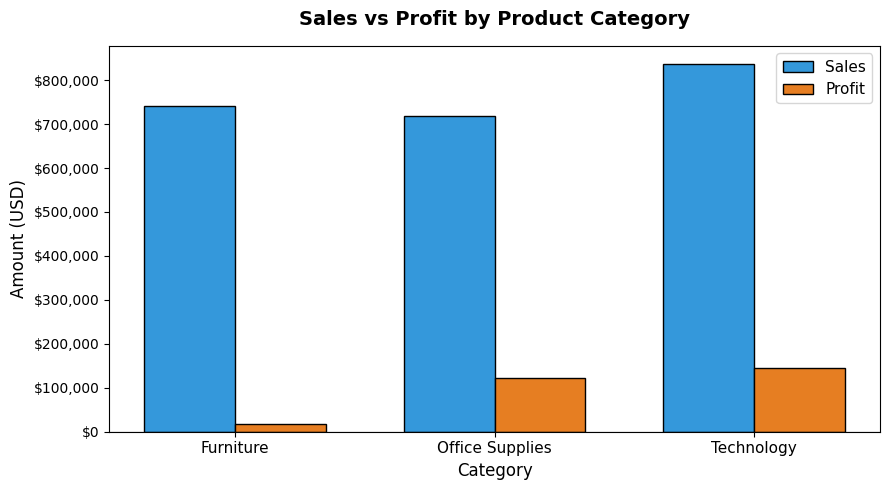

In [116]:
# Chart 2: Category wise Sales vs Profit (Grouped Bar)
cat_data = df.groupby('category')[['sales', 'profit']].sum()

x = np.arange(len(cat_data.index))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, cat_data['sales'],
               width, label='Sales', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, cat_data['profit'],
               width, label='Profit', color='#e67e22', edgecolor='black')

ax.set_title('Sales vs Profit by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Amount (USD)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cat_data.index, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('chart2_category_sales_profit.png', dpi=150)
plt.show()


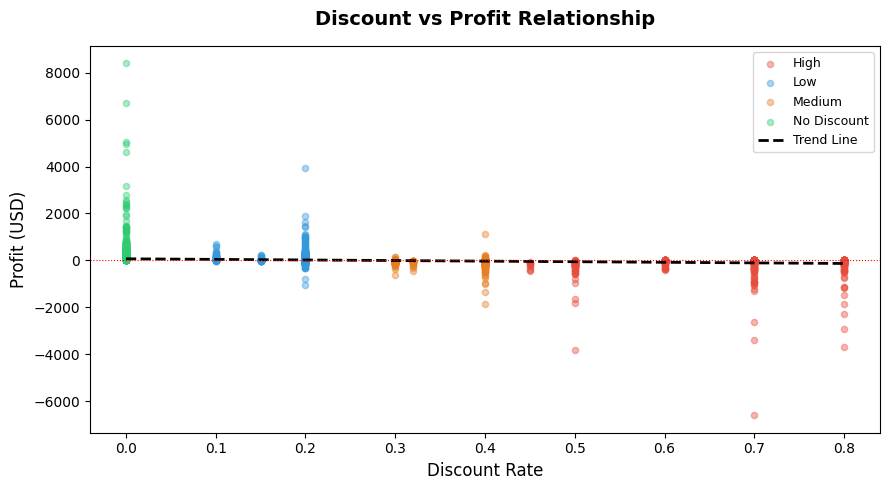

Correlation between Discount and Profit: -0.2195


In [117]:
# Chart 3: Discount vs Profit Scatter Plot (Relationship Analysis)
fig, ax = plt.subplots(figsize=(9, 5))

colors_map = {'No Discount': '#2ecc71', 'Low': '#3498db',
              'Medium': '#e67e22', 'High': '#e74c3c'}

for cat, group in df.groupby('discount_category'):
    ax.scatter(group['discount'], group['profit'],
               alpha=0.4, s=20,
               color=colors_map.get(cat, 'gray'),
               label=cat)


z = np.polyfit(df['discount'], df['profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['discount'].min(), df['discount'].max(), 100)
ax.plot(x_line, p(x_line), color='black',
        linewidth=2, linestyle='--', label='Trend Line')

ax.set_title('Discount vs Profit Relationship', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Discount Rate', fontsize=12)
ax.set_ylabel('Profit (USD)', fontsize=12)
ax.axhline(0, color='red', linewidth=0.8, linestyle=':')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart3_discount_profit.png', dpi=150)
plt.show()

corr = df['discount'].corr(df['profit'])

print(f"Correlation between Discount and Profit: {corr:.4f}")

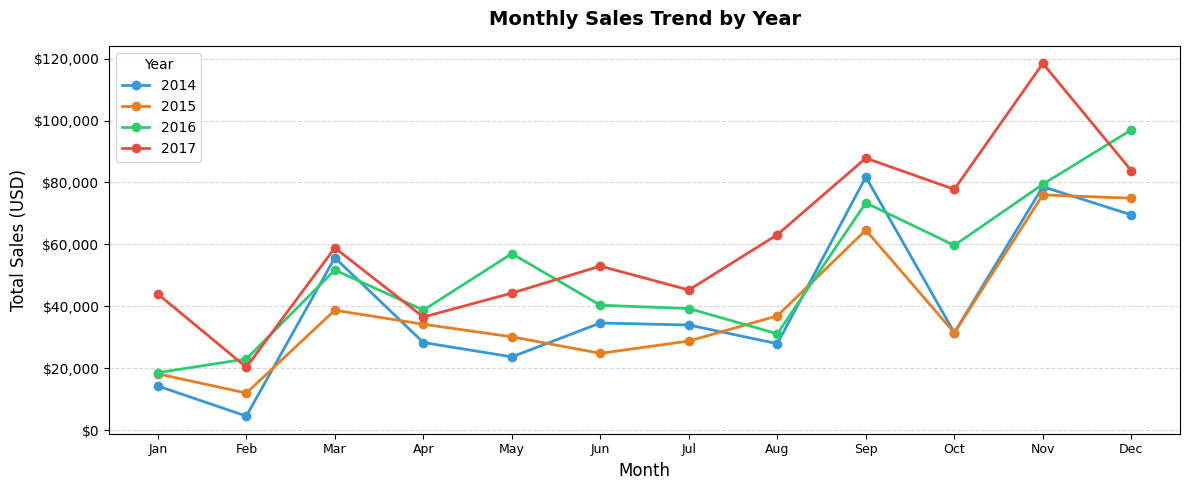

In [118]:
# Chart 4: Monthly Sales Trend Over Years
monthly = df.groupby(['order_year', 'order_month'])['sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

colors_year = {2014: '#3498db', 2015: '#e67e22',
               2016: '#2ecc71', 2017: '#e74c3c'}

for year in sorted(monthly['order_year'].unique()):
    data = monthly[monthly['order_year'] == year]
    ax.plot(data['order_month'], data['sales'],
            marker='o', linewidth=2,
            label=str(year),
            color=colors_year.get(year, 'gray'))

ax.set_title('Monthly Sales Trend by Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales (USD)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Year', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart4_monthly_trend.png', dpi=150)
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_5612\1008029377.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(profit_by_cat,


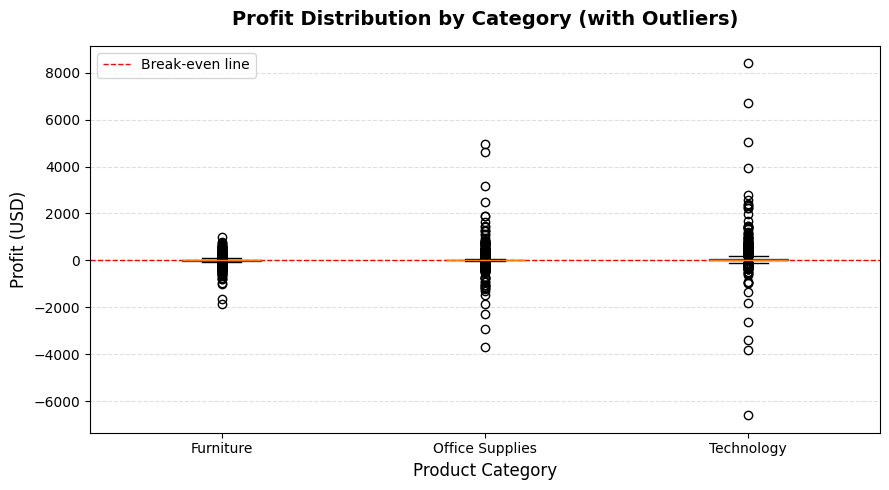

In [119]:
# Chart 5: Profit Distribution by Category (Box Plot)
categories = df['category'].unique()
profit_by_cat = [df[df['category'] == cat]['profit'].values for cat in categories]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(profit_by_cat,
                patch_artist=True,
                notch=False,
                labels=categories)

box_colors = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Profit Distribution by Category (with Outliers)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Profit (USD)', fontsize=12)
ax.axhline(0, color='red', linewidth=1, linestyle='--', label='Break-even line')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('chart5_profit_boxplot.png', dpi=150)
plt.show()


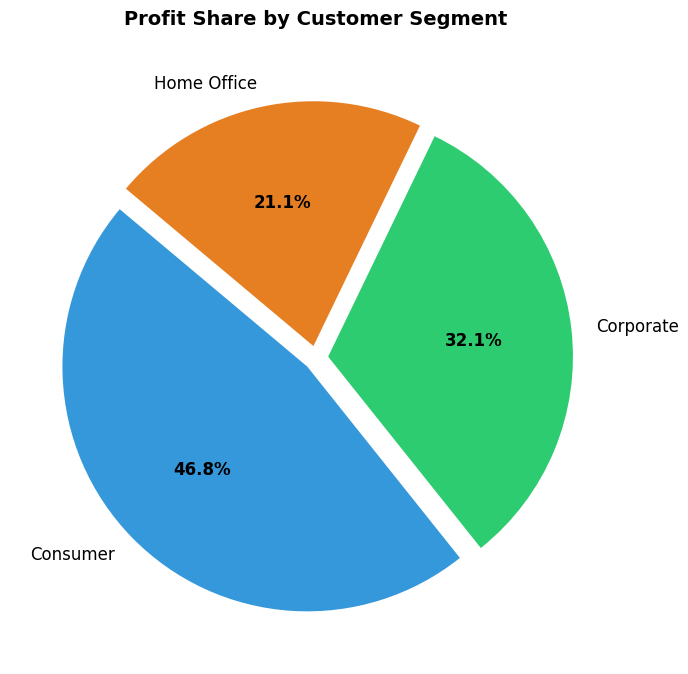

In [120]:
# Chart 6: Customer Segment Profit Share (Pie Chart)
segment_profit = df.groupby('segment')['profit'].sum()

fig, ax = plt.subplots(figsize=(7, 7))

colors_pie = ['#3498db', '#2ecc71', '#e67e22']
explode = [0.05] * len(segment_profit)

wedges, texts, autotexts = ax.pie(
    segment_profit.values,
    labels=segment_profit.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=explode,
    startangle=140,
    textprops={'fontsize': 12}
)

for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Profit Share by Customer Segment', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart6_segment_pie.png', dpi=150)
plt.show()


In [127]:

# SECTION 7: FINDINGS



print("KEY FINDINGS FROM ANALYSIS")
print("-" * 30)

# Finding 1
region_profit = df.groupby('region')['profit'].sum()
best_region = region_profit.idxmax()
worst_region = region_profit.idxmin()

print(f"""
FINDING 1: Regional Profit Disparity

The '{best_region}' region is the most profitable with a total 
profit of ${region_profit[best_region]:,.2f}, while the 
'{worst_region}' region performs the worst with only 
${region_profit[worst_region]:,.2f} in profit.
This suggests that regional strategy and customer base 
differ significantly across the country.
""")

# Finding 2
cat_profit = df.groupby('category')['profit'].sum()
best_cat = cat_profit.idxmax()
worst_cat = cat_profit.idxmin()

print(f"""
FINDING 2: Technology Leads, Furniture Struggles

'{best_cat}' is the most profitable category (${cat_profit[best_cat]:,.2f}),
while '{worst_cat}' generates the least profit (${cat_profit[worst_cat]:,.2f}).
Despite Furniture having high sales volume, its profit margin
is very low — indicating high costs or excessive discounting.
""")

# Finding 3
corr = round(df['discount'].corr(df['profit']), 4)
high_disc = df[df['discount_category'] == 'High']['profit'].mean()
no_disc   = df[df['discount_category'] == 'No Discount']['profit'].mean()

display(Markdown("""
FINDING 3: Higher Discounts Destroy Profit

Correlation between discount and profit is {corr}, 
confirming a strong negative relationship.
Orders with No Discount have an average profit of ${no_disc:,.2f},
while High Discount orders average ${high_disc:,.2f} in profit.
The business is losing money by offering large discounts.
"""))

# Finding 4
best_quarter = df.groupby('order_quarter')['sales'].sum().idxmax()
q_sales = df.groupby('order_quarter')['sales'].sum()

display(Markdown("""
FINDING 4: Q4 is the Strongest Sales Period

Quarter {best_quarter} consistently generates the highest sales 
across all years (${q_sales[best_quarter]:,.2f} total).
November and December show the highest spikes, likely 
driven by holiday season demand. Business should prepare 
higher inventory and staffing during Q4.
"""))

# Finding 5
Q1 = df['profit'].quantile(0.25)
Q3 = df['profit'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['profit'] < Q1 - 1.5*IQR) | (df['profit'] > Q3 + 1.5*IQR)]
loss_orders = df[df['profit'] < 0]

display(Markdown("""
FINDING 5: Significant Loss-Making Orders Exist

{len(loss_orders)} orders ({(len(loss_orders)/len(df)*100):.1f}% of all orders) 
resulted in a financial loss for the business.
Outlier analysis identified {len(outliers)} extreme profit/loss orders.
Most loss-making outliers belong to the Furniture and 
Office Supplies categories with heavy discounts applied.
"""))

# Finding 6
seg_profit = df.groupby('segment')['profit'].sum()
best_seg = seg_profit.idxmax()

display(Markdown("""
FINDING 6: Consumer Segment is Most Valuable

The '{best_seg}' customer segment contributes the most 
to overall profit (${seg_profit[best_seg]:,.2f}).
Corporate segment follows closely, while Home Office 
contributes the least. Marketing efforts should be 
prioritized toward Consumer and Corporate segments.
"""))

KEY FINDINGS FROM ANALYSIS
------------------------------

FINDING 1: Regional Profit Disparity

The 'West' region is the most profitable with a total 
profit of $108,418.45, while the 
'Central' region performs the worst with only 
$39,706.36 in profit.
This suggests that regional strategy and customer base 
differ significantly across the country.


FINDING 2: Technology Leads, Furniture Struggles

'Technology' is the most profitable category ($145,454.95),
while 'Furniture' generates the least profit ($18,451.27).
Despite Furniture having high sales volume, its profit margin
is very low — indicating high costs or excessive discounting.




FINDING 3: Higher Discounts Destroy Profit

Correlation between discount and profit is {corr}, 
confirming a strong negative relationship.
Orders with No Discount have an average profit of ${no_disc:,.2f},
while High Discount orders average ${high_disc:,.2f} in profit.
The business is losing money by offering large discounts.



FINDING 4: Q4 is the Strongest Sales Period

Quarter {best_quarter} consistently generates the highest sales 
across all years (${q_sales[best_quarter]:,.2f} total).
November and December show the highest spikes, likely 
driven by holiday season demand. Business should prepare 
higher inventory and staffing during Q4.



FINDING 5: Significant Loss-Making Orders Exist

{len(loss_orders)} orders ({(len(loss_orders)/len(df)*100):.1f}% of all orders) 
resulted in a financial loss for the business.
Outlier analysis identified {len(outliers)} extreme profit/loss orders.
Most loss-making outliers belong to the Furniture and 
Office Supplies categories with heavy discounts applied.



FINDING 6: Consumer Segment is Most Valuable

The '{best_seg}' customer segment contributes the most 
to overall profit (${seg_profit[best_seg]:,.2f}).
Corporate segment follows closely, while Home Office 
contributes the least. Marketing efforts should be 
prioritized toward Consumer and Corporate segments.


In [125]:

print("LIMITATIONS OF THIS ANALYSIS")
print("-" * 30)

display(Markdown("""
LIMITATION 1: No Customer Demographics Data

The dataset does not include customer age, gender, or 
income level. This limits our ability to perform deeper 
customer segmentation or targeted marketing analysis.

LIMITATION 2: Correlation Does Not Imply Causation

Although we found a negative correlation between discount 
and profit, we cannot conclude that discounts alone cause 
losses. Other factors like shipping cost, product cost, 
and return rates may also contribute.

LIMITATION 3: No Cost or Return Data

The dataset does not include product cost, operational 
expenses, or return/refund data. This means our profit 
analysis is based only on the profit column provided, 
which may not reflect true net profit.


LIMITATION 4: Geographic Granularity

Analysis is limited to 4 broad regions (East, West, 
Central, South). City-level or state-level analysis 
would provide much more actionable business insights.

LIMITATION 5: Dataset Time Range

The dataset covers 2014 to 2017 only. Business trends, 
market conditions, and consumer behavior may have 
changed significantly since then. Findings may not 
apply to current business decisions.
"""))

LIMITATIONS OF THIS ANALYSIS
------------------------------



LIMITATION 1: No Customer Demographics Data

The dataset does not include customer age, gender, or 
income level. This limits our ability to perform deeper 
customer segmentation or targeted marketing analysis.

LIMITATION 2: Correlation Does Not Imply Causation

Although we found a negative correlation between discount 
and profit, we cannot conclude that discounts alone cause 
losses. Other factors like shipping cost, product cost, 
and return rates may also contribute.

LIMITATION 3: No Cost or Return Data

The dataset does not include product cost, operational 
expenses, or return/refund data. This means our profit 
analysis is based only on the profit column provided, 
which may not reflect true net profit.


LIMITATION 4: Geographic Granularity

Analysis is limited to 4 broad regions (East, West, 
Central, South). City-level or state-level analysis 
would provide much more actionable business insights.

LIMITATION 5: Dataset Time Range

The dataset covers 2014 to 2017 only. Business trends, 
market conditions, and consumer behavior may have 
changed significantly since then. Findings may not 
apply to current business decisions.


In [126]:
print("CONCLUSION")
print("-" * 20)

total_sales  = df['sales'].sum()
total_profit = df['profit'].sum()
overall_margin = (total_profit / total_sales * 100)

display(Markdown("""
This project analyzed the Superstore sales dataset to
investigate business performance across regions, product
categories, customer segments, and time periods.

OVERALL BUSINESS PERFORMANCE:
  Total Revenue Generated : ${total_sales:,.2f}
  Total Profit Earned     : ${total_profit:,.2f}
  Overall Profit Margin   : {overall_margin:.2f}%

THREE CORE QUESTIONS — ANSWERED:

Q1. Which regions and categories are most profitable?
    → West region and Technology category lead in profit.
      Central region and Furniture category need attention.

Q2. Does discounting increase sales but reduce profit?
    → Yes. High discounts strongly correlate with losses.
      The business should revise its discounting strategy.

Q3. What seasonal trends affect sales performance?
    → Q4 (Oct-Dec) is consistently the best quarter.
      Business should plan inventory and campaigns for Q4.

RECOMMENDATION:
The business should reduce heavy discounting especially
in the Furniture category, invest more in the West and
East regions, focus marketing on Consumer and Corporate
segments, and prepare stronger Q4 inventory planning.

This analysis was conducted using Python (Pandas, NumPy,
Matplotlib) on the Sample Superstore dataset obtained
from Kaggle.
"""))

CONCLUSION
--------------------



This project analyzed the Superstore sales dataset to
investigate business performance across regions, product
categories, customer segments, and time periods.

OVERALL BUSINESS PERFORMANCE:
  Total Revenue Generated : ${total_sales:,.2f}
  Total Profit Earned     : ${total_profit:,.2f}
  Overall Profit Margin   : {overall_margin:.2f}%

THREE CORE QUESTIONS — ANSWERED:

Q1. Which regions and categories are most profitable?
    → West region and Technology category lead in profit.
      Central region and Furniture category need attention.

Q2. Does discounting increase sales but reduce profit?
    → Yes. High discounts strongly correlate with losses.
      The business should revise its discounting strategy.

Q3. What seasonal trends affect sales performance?
    → Q4 (Oct-Dec) is consistently the best quarter.
      Business should plan inventory and campaigns for Q4.

RECOMMENDATION:
The business should reduce heavy discounting especially
in the Furniture category, invest more in the West and
East regions, focus marketing on Consumer and Corporate
segments, and prepare stronger Q4 inventory planning.

This analysis was conducted using Python (Pandas, NumPy,
Matplotlib) on the Sample Superstore dataset obtained
from Kaggle.
